# Step 2 — 1D Nonlinear Convection

*13 Steps to Navier-Stokes with somax (inspired by Lorena Barba's CFD Python)*

In Step 1 we saw linear convection: a wave translating at constant speed. Now we let the wave speed depend on the solution itself. This seemingly small change introduces dramatic new physics — steepening fronts, shock formation, and the need for upwind schemes.

**What you'll learn:**

1. How nonlinear self-advection steepens wave profiles
2. Why upwind flux reconstruction is essential for stability
3. How to track energy conservation in a nonlinear system
4. How to differentiate through the nonlinear simulation

## The PDE

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0
$$

This is the **inviscid Burgers equation** — the simplest nonlinear hyperbolic conservation law. It can be written in conservative form:

$$
\frac{\partial u}{\partial t} + \frac{\partial}{\partial x}
\left( \frac{u^2}{2} \right) = 0
$$

### Self-steepening

The wave speed is $u$ itself: regions with larger amplitude travel faster. The crest of a positive bump outruns the trough, causing the leading edge to steepen until a **shock** (discontinuity) forms in finite time. After the shock, the classical solution breaks down and one needs weak (entropy) solutions.

In our discrete simulation, the upwind scheme adds enough numerical dissipation to keep the solution stable through mild steepening, but we deliberately stop before a strong shock develops.

## Grid layout and boundary conditions

somax uses the **Arakawa C-grid** from finitevolX. In 1D, scalar fields (like $u$) live at **T-points** (cell centres) and fluxes are computed at **U-points** (cell edges):

```
 ghost                    interior                     ghost
 ┌─────┬──────┬──────┬──────┬──────┬──────┬──────┬─────┐
 │  G  │  T₁  │  T₂  │  T₃  │ ···  │ Tₙ₋₁│  Tₙ  │  G  │
 └──┬──┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬──┘
    U₀    U₁     U₂     U₃           Uₙ₋₁    Uₙ    Uₙ₊₁
         ←── dx ──→
```

- **T-points** (indices `1:-1`): where `u` is stored and updated
- **U-points**: where upwind flux reconstruction computes the nonlinear advection term $\partial(u^2/2)/\partial x$
- **Ghost cells** (indices `0` and `-1`): filled by BCs before each RHS evaluation

**Periodic BCs** copy the last interior value into the opposite ghost cell:

```
 u[0] = u[-2]      (left ghost ← rightmost interior)
 u[-1] = u[1]      (right ghost ← leftmost interior)
```

This makes the domain wrap around so waves that exit one side re-enter from the other.

In [1]:
from __future__ import annotations

import diffrax as dfx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import NonlinearConvection1D, NonlinearConvection1DState

## 1. Create the model

`NonlinearConvection1D` has no learnable parameters (the wave speed is the solution itself). The model uses upwind flux reconstruction for stability.

In [2]:
nx, Lx = 200, 4.0
model = NonlinearConvection1D.create(nx=nx, Lx=Lx)

print(f"Grid: Nx={model.grid.Nx}, dx={model.grid.dx:.4f}")
print(f"Advection method: {model.method}")

Grid: Nx=202, dx=0.0200
Advection method: upwind1


## 2. Initial condition

A Gaussian bump centered at $x = 1.5$ with amplitude 1. The positive values mean the entire bump travels to the right, but faster at the peak than at the tails.

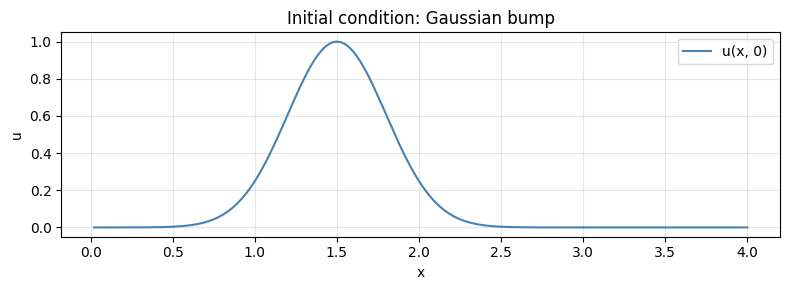

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx

mu0, sigma0 = 1.5, 0.3
u0 = jnp.exp(-0.5 * ((x - mu0) / sigma0) ** 2)

state0 = NonlinearConvection1DState(u=u0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x[1:-1], u0[1:-1], color="steelblue", lw=1.5, label="u(x, 0)")
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("Initial condition: Gaussian bump")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forward simulation — watching the profile steepen

We save snapshots at several times to visualize how the leading edge steepens while the trailing edge stretches.

In [4]:
t0, t1, dt = 0.0, 0.4, 0.002
ts = jnp.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.4])

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Trajectory shape: u={sol.ys.u.shape}")

Trajectory shape: u=(6, 202)


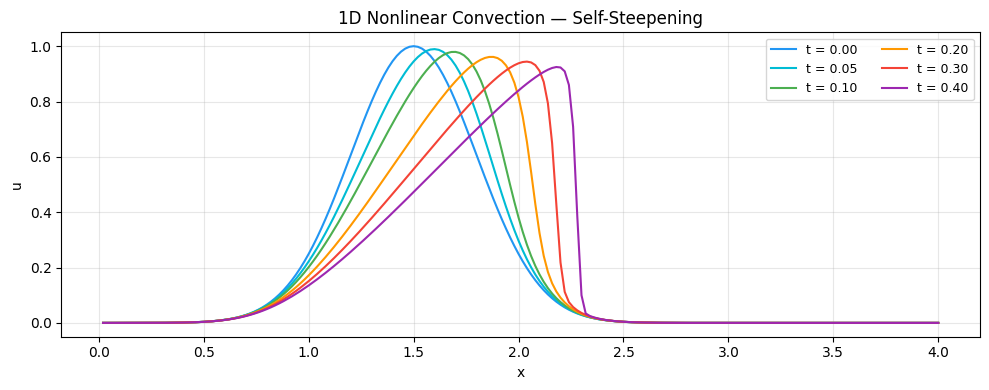

In [5]:
colors_snap = ["#2196F3", "#00BCD4", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]

fig, ax = plt.subplots(figsize=(10, 4))
for i, t_snap in enumerate(ts):
    ax.plot(
        x[1:-1],
        sol.ys.u[i, 1:-1],
        color=colors_snap[i],
        lw=1.5,
        label=f"t = {float(t_snap):.2f}",
    )
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("1D Nonlinear Convection — Self-Steepening")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Notice how the right edge of the bump steepens: the peak (where $u$ is largest) outruns the base (where $u$ is smaller). This is the hallmark of nonlinear advection.

## 4. Comparing with linear convection

To highlight the nonlinear effect, we overlay the nonlinear result with a pure translation (what linear convection would give for the same initial bump).

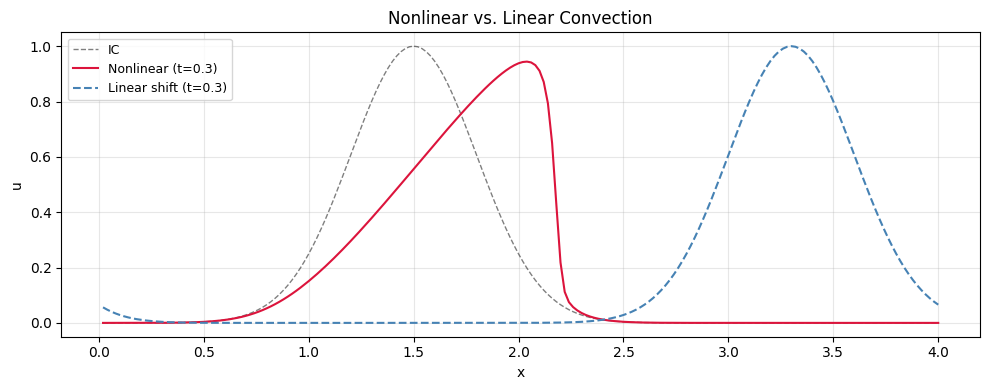

In [6]:
t_compare = 0.3
idx_compare = 4  # corresponds to ts[4] = 0.3

# Linear convection would shift the Gaussian by c*t.
# For nonlinear convection, the "effective speed" varies, but the
# peak was initially at u~1, so it moves at roughly speed 1.
u_linear_approx = jnp.exp(
    -0.5 * (((x - mu0 - 1.0 * t_compare) % Lx - mu0) / sigma0) ** 2
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x[1:-1], u0[1:-1], "k--", lw=1.0, alpha=0.5, label="IC")
ax.plot(
    x[1:-1],
    sol.ys.u[idx_compare, 1:-1],
    color="crimson",
    lw=1.5,
    label=f"Nonlinear (t={t_compare})",
)
ax.plot(
    x[1:-1],
    u_linear_approx[1:-1],
    color="steelblue",
    lw=1.5,
    ls="--",
    label=f"Linear shift (t={t_compare})",
)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("Nonlinear vs. Linear Convection")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Energy evolution

For the inviscid Burgers equation, the $L^2$ energy $E = \frac{1}{2} \int u^2 \, dx$ is conserved analytically (before shock formation). Numerically, the upwind scheme introduces dissipation — this is actually desirable as it provides the entropy condition needed to select the physically correct weak solution.

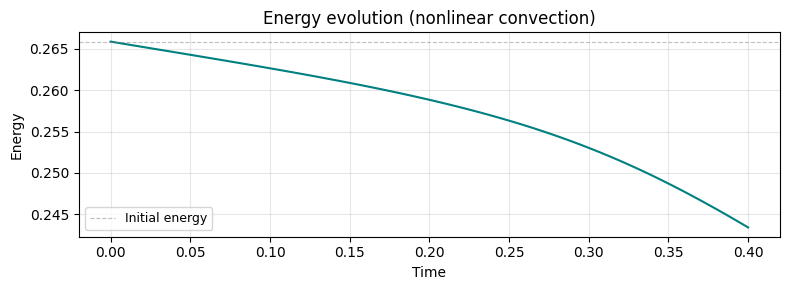

Energy: initial = 0.265868, final = 0.243400
Relative change: 8.4509%


In [7]:
ts_dense = jnp.linspace(t0, t1, 100)
sol_dense = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts_dense),
)

energy = jax.vmap(model.diagnose)(sol_dense.ys).energy

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ts_dense, energy, color="teal", lw=1.5)
ax.axhline(
    float(energy[0]), color="gray", ls="--", lw=0.8, alpha=0.5, label="Initial energy"
)
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.set_title("Energy evolution (nonlinear convection)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Energy: initial = {float(energy[0]):.6f}, final = {float(energy[-1]):.6f}")
print(f"Relative change: {abs(float(energy[-1] - energy[0])) / float(energy[0]):.4%}")

## 6. A note on upwind schemes and stability

The nonlinear convection equation requires careful numerical treatment:

- **Upwind schemes** bias the stencil in the direction from which information propagates. somax uses `"upwind1"` (first-order upwind) by default, which is diffusive but unconditionally entropy-stable.
- **Central differences** (what you might try first) are unstable for hyperbolic equations — they produce unphysical oscillations.
- **Higher-order methods** (WENO, PPM) reduce numerical diffusion while maintaining stability near shocks.

The CFL condition for Burgers' equation uses the maximum wave speed: $\Delta t \le \Delta x / \max|u|$.

In [8]:
cfl = float(jnp.max(jnp.abs(u0))) * dt / model.grid.dx
print(f"CFL number (initial): max|u| * dt / dx = {cfl:.3f}")

CFL number (initial): max|u| * dt / dx = 0.100


## 7. Differentiability demo

Even though the model has no explicit learnable parameters, we can still differentiate with respect to the **initial condition**. This is useful for data assimilation and optimal control.

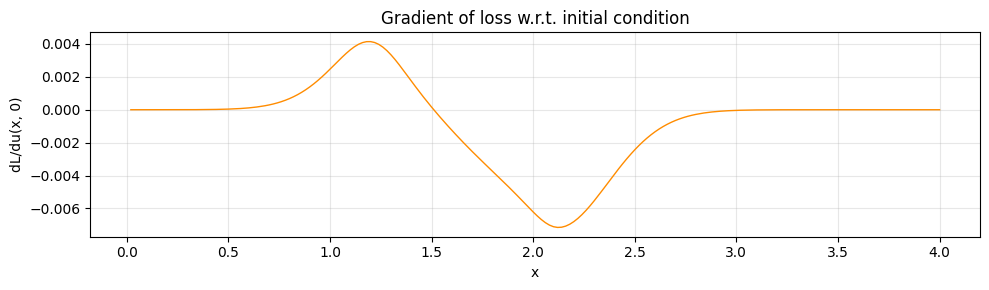

Max |dL/du0|: 0.007150


In [9]:
def loss_fn(state_init):
    """MSE between final profile and a target shifted Gaussian."""
    sol = model.integrate(state_init, t0=0.0, t1=0.2, dt=0.002)
    u_pred = sol.ys.u[-1]
    u_target = jnp.exp(-0.5 * ((x - 2.0) / sigma0) ** 2)
    return jnp.mean((u_pred[1:-1] - u_target[1:-1]) ** 2)


grad_u0 = jax.grad(loss_fn)(state0)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x[1:-1], grad_u0.u[1:-1], color="darkorange", lw=1.0)
ax.set_xlabel("x")
ax.set_ylabel("dL/du(x, 0)")
ax.set_title("Gradient of loss w.r.t. initial condition")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max |dL/du0|: {float(jnp.max(jnp.abs(grad_u0.u[1:-1]))):.6f}")

## Summary

| Concept | somax API |
|---------|-----------|
| Create model | `NonlinearConvection1D.create(nx=200, Lx=4.0)` |
| Initial state | `NonlinearConvection1DState(u=...)` |
| Forward sim | `model.integrate(state0, t0, t1, dt, saveat=...)` |
| Energy check | `model.diagnose(state).energy` |
| Grad w.r.t. IC | `jax.grad(loss)(state0)` |

**Key takeaway:** Nonlinear convection causes self-steepening — the wave speed depends on amplitude. Upwind schemes provide the numerical dissipation needed for stability.

**Next:** [Step 3 — Diffusion](step03_diffusion_1d) introduces viscosity, which smooths gradients and dissipates energy.